# IPP Documentation Assessment Data Analysis

Analysis of student documentation submissions and grader feedback, IPP 2013 to 2024. Implemented with a custom assessment `.csv` parser.

In [36]:
%load_ext autoreload
%autoreload 3

import logging

import matplotlib.pyplot as plt
import seaborn as sns
from scripts import dataset_analysis as da
from scripts import dataset_parser
from scripts import visual_utils as vu

logging.basicConfig(level=logging.INFO, force=True)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

vu.configure_plot_style()

dataset_parser.main()
df = da.load_clean_data()
proj = da.build_project_df(df)

INFO:scripts.dataset_parser:Found 0 files in /home/matut/git-projects/doc-grader/notebooks/data/ipp/assessments
INFO:scripts.dataset_parser:No data extracted.


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Dataset Overview

In [37]:
da.analyse_volume(df, proj)

INFO:scripts.dataset_analysis:Total projects: 8231


INFO:scripts.dataset_analysis:Total files: 21
INFO:scripts.dataset_analysis:Total unique codes used: 57
INFO:scripts.dataset_analysis:Year range: ('2014', '2024')
INFO:scripts.dataset_analysis:Task Variants: ['int', 'par', 'php', 'py']
INFO:scripts.dataset_analysis:Total grading events: 25918
INFO:scripts.dataset_analysis:Total grading events with impacts: 15701


### Task Variants

The `php`/`py` labels were renamed to `par`/`int` in 2017. In 2017 specifically, int was the one and only Task.

In [38]:
ax = da.visualise_task_variant_distribution(proj)

### Document Format

PDF was introduced in 2018, before that all submissions were Markdown.

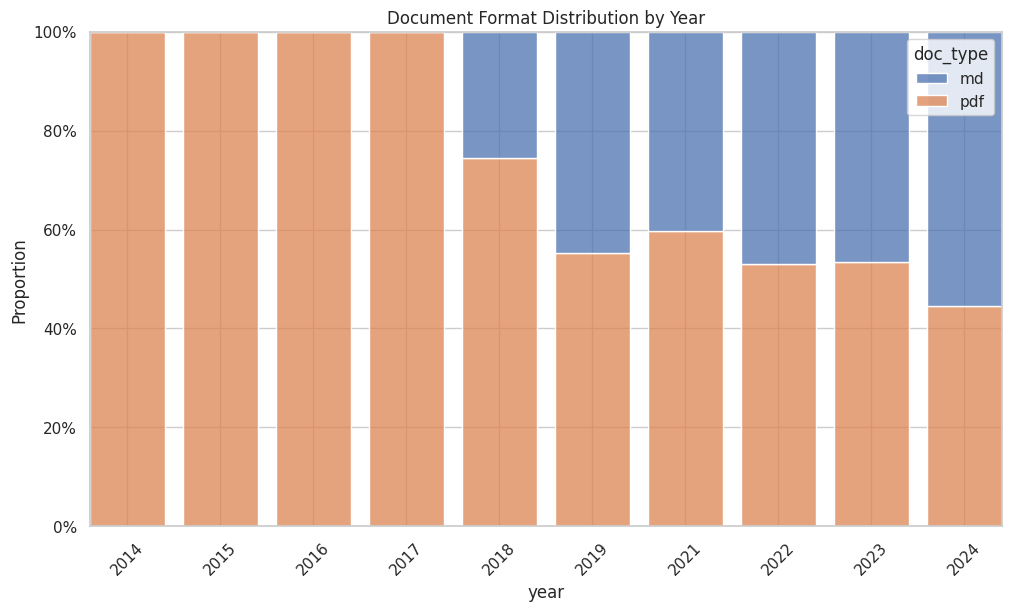

In [39]:
ax = da.visualise_doc_type_distribution(proj)

## 2. Score Outcomes

### Documentation Deduction Distribution

Most students receive zero or near-zero deductions.

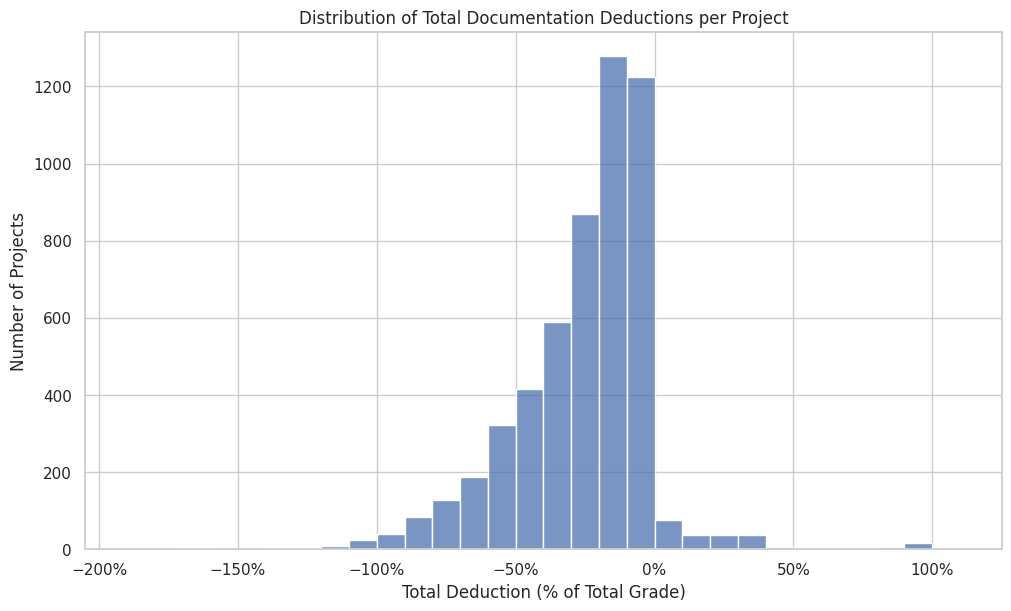

INFO:scripts.dataset_analysis:Projects with 0 deductions: 570 / 8231 (6.9%)


In [40]:
ax = da.visualise_total_impact_distribution(proj)
da.summarise_score_imbalance(proj)

### Score by Year and Task Variant

Mean documentation score (% of maximum) per year. Shaded area shows 95% confidence interval.

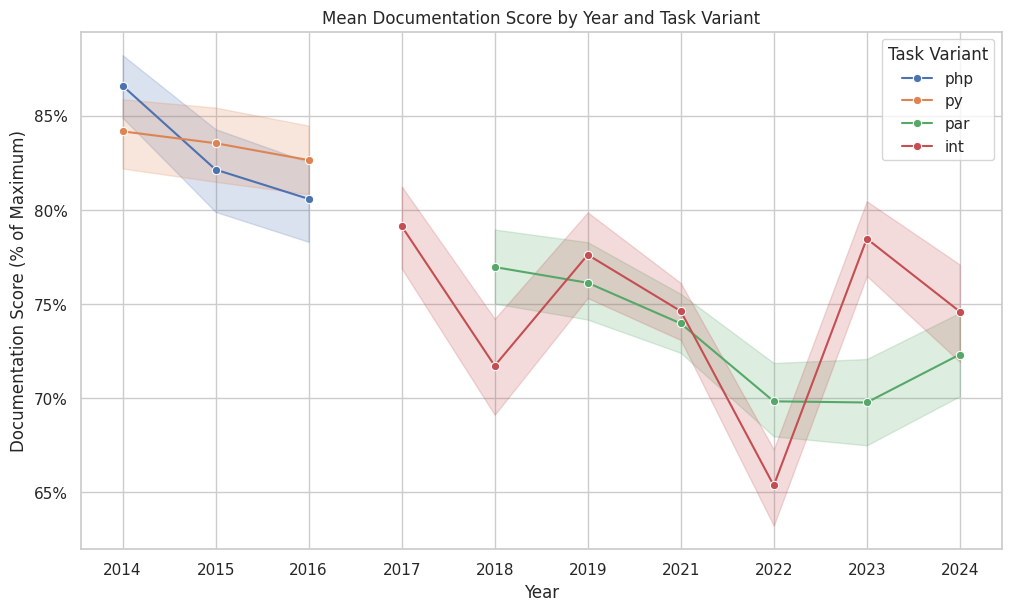

In [41]:
from matplotlib.ticker import PercentFormatter

score_data = proj.dropna(subset=["doc_score_pct"])

fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
sns.lineplot(
    data=score_data,
    x="year",
    y="doc_score_pct",
    hue="task_variant",
    hue_order=list(vu.TASK_VARIANT_PALETTE),
    palette=vu.TASK_VARIANT_PALETTE,
    marker="o",
    errorbar=("ci", 95),
    ax=ax,
)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.set_title("Mean Documentation Score by Year and Task Variant")
ax.set_xlabel("Year")
ax.set_ylabel("Documentation Score (% of Maximum)")
ax.legend(title="Task Variant")
plt.show()

### Score Distribution by Task Variant
Whiskers extend to the 5th/95th percentile.

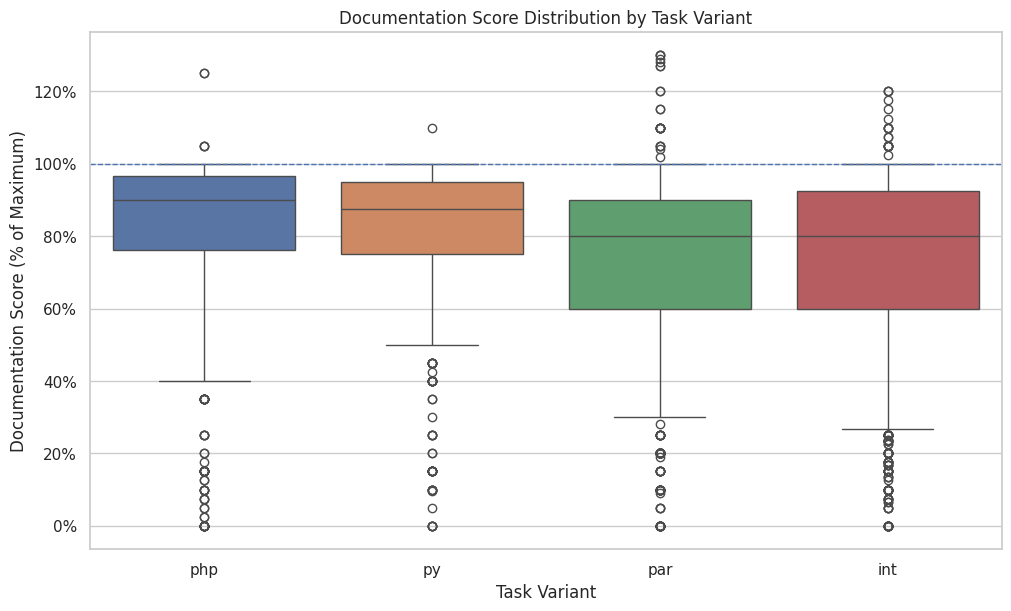

In [42]:
from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
sns.boxplot(
    data=score_data,
    x="task_variant",
    y="doc_score_pct",
    hue="task_variant",
    order=list(vu.TASK_VARIANT_PALETTE),
    palette=vu.TASK_VARIANT_PALETTE,
    legend=False,
    whis=(5, 95),
    ax=ax,
)
ax.axhline(100, linestyle="--", linewidth=1)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.set_title("Documentation Score Distribution by Task Variant")
ax.set_xlabel("Task Variant")
ax.set_ylabel("Documentation Score (% of Maximum)")
plt.show()

Bonuses can bring documentation score over 100%

### Format Impact

PDF students score higher on documentation, the cumulative distribution sits mostly above Markdown.

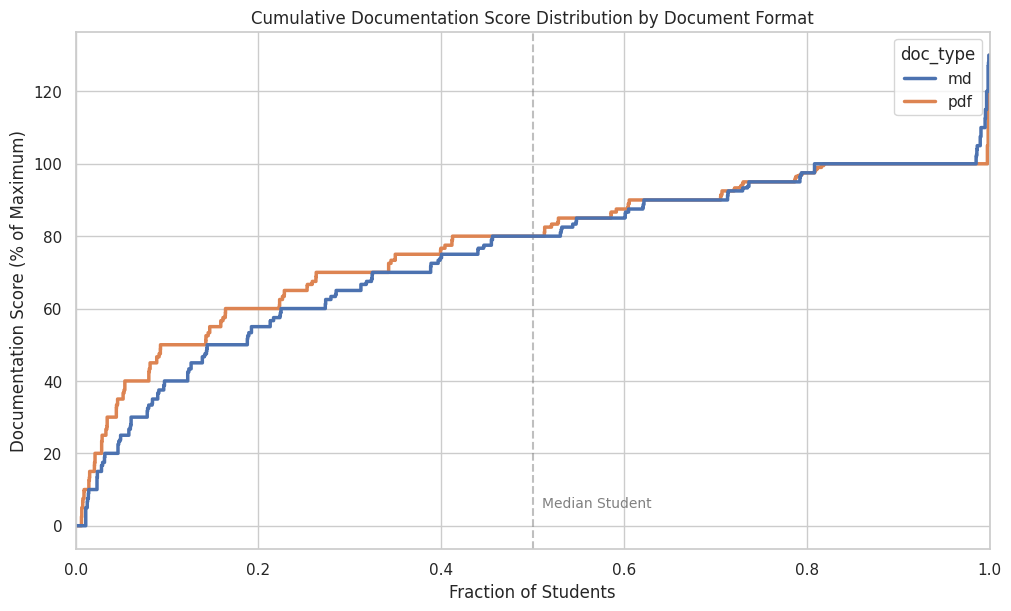

,count,mean,median
doc_type,,,
md,2438,74.43,80.0
pdf,5793,77.24,80.0


In [43]:
format_impact_df = da.analyse_format_impact(proj)
ax = da.visualise_format_impact(format_impact_df)
da.summarise_format_impact(format_impact_df)

## 3. Code Frequency

How often each grading code appears across all submissions.

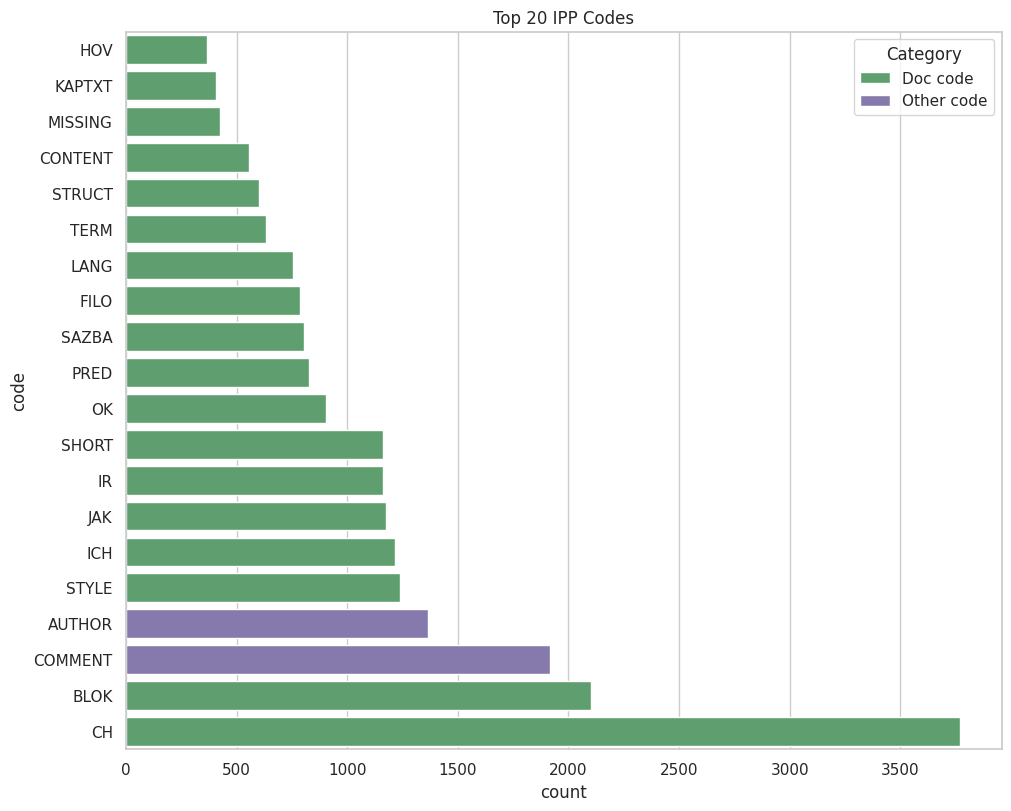

In [44]:
ax = da.visualise_code_frequency(df, n_codes=20)

## 4. Code Impact

Impact values are expressed as a fraction of the year/variant maximum, making them comparable across years. Shared penalties (e.g. `STRUCT/SHORT`) are excluded.

### Most and Least Impactful Codes

In [45]:
impact_stats = da.analyse_impact_statistics(df)
frequent = impact_stats[impact_stats["count"] >= 10]

print("Top 10 harshest codes:")
display(frequent.head(10))

print("\nCodes almost always applied as actual deductions:")
display(
    frequent[
        (frequent["pct_no_impact"] < 0.15) & (frequent["median"] < 0)
    ].sort_values("count", ascending=False).head(5)
)

print("\nCodes almost always applied as bonus points:")
display(
    frequent[frequent["median"] > 0].sort_values("count", ascending=False).head(5)
)

print("\nCodes almost always applied as informative warnings:")
display(
    impact_stats[
        ((impact_stats["pct_no_impact"] >= 0.80) | (impact_stats["median"] == 0))
        & (impact_stats["total"] >= 10)
    ].sort_values("total", ascending=False).head(5)
)

Top 10 harshest codes:


,code,total,pct_no_impact,count,mean,median,std,min,max
26,MISSING,423,0.295508,293,-0.383248,-0.250000,0.226881,-1.000000,0.066667
44,STN0,27,0.000000,27,-0.250000,-0.250000,0.000000,-0.250000,-0.250000
29,NOUML,117,0.213675,90,-0.217222,-0.250000,0.040010,-0.250000,-0.166667
40,SHORT,1161,0.220500,753,-0.209060,-0.150000,0.158301,-0.850000,-0.012500
8,COPY,40,0.300000,18,-0.183796,-0.137500,0.139574,-0.500000,-0.033333
45,STN1,22,0.045455,21,-0.150000,-0.150000,0.000000,-0.150000,-0.150000
56,WHY,22,0.136364,19,-0.147368,-0.150000,0.045563,-0.200000,-0.050000
21,JAK,1177,0.159728,900,-0.144116,-0.100000,0.086512,-0.500000,0.050000
13,EXT,168,0.011905,144,-0.133796,-0.166667,0.041154,-0.166667,-0.033333
46,STN2,30,0.033333,29,-0.125000,-0.125000,0.000000,-0.125000,-0.125000



Codes almost always applied as actual deductions:


,code,total,pct_no_impact,count,mean,median,std,min,max
20,IR,1161,0.078381,980,-0.115564,-0.100,0.067272,-0.500000,0.100000
14,FILO,787,0.116900,579,-0.089781,-0.075,0.053943,-0.500000,0.100000
23,LANG,756,0.146825,574,-0.054483,-0.050,0.042629,-0.300000,0.000000
43,SRCFORMAT,309,0.055016,283,-0.062547,-0.050,0.047640,-0.250000,0.000000
2,BADUML,283,0.116608,227,-0.102093,-0.100,0.062796,-0.333333,-0.016667



Codes almost always applied as bonus points:


,code,total,pct_no_impact,count,mean,median,std,min,max
34,OOP,262,0.225191,202,0.061073,0.100,0.208716,-1.000000,0.300
51,STN9,213,0.244131,161,0.185870,0.250,0.089138,-0.125000,0.250
31,NVP,167,0.568862,72,0.164583,0.075,0.690756,-1.000000,1.000
38,PSR12,79,0.189873,64,0.125000,0.125,0.000000,0.125000,0.125
12,EX,59,0.033898,56,0.098512,0.100,0.039058,0.016667,0.200



Codes almost always applied as informative warnings:


,code,total,pct_no_impact,count,mean,median,std,min,max
3,BLOK,2103,0.788398,337,-0.000297,0.0,0.018896,-0.100000,0.25
0,AUTHOR,1364,0.681085,434,-0.001037,0.0,0.013659,-0.200000,0.00
19,ICH,1216,0.643092,386,-0.001749,0.0,0.012221,-0.150000,0.00
33,OK,902,0.991131,8,0.187500,0.1,0.346152,-0.100000,1.00
36,PRED,828,0.729469,180,-0.000926,0.0,0.012423,-0.166667,0.00


### Impact Distribution

Box + strip chart showing the spread of point impacts per code.

In [46]:
ax = da.visualise_impact_boxplots(df, n_codes=15)

### High-Variance Codes

Codes with normalised std > 0.07 and at least 10 occurrences. Some are often used for both bonuses and penalties, others are likely more subjectively graded.

High-variance codes: ['MISSING', 'SHORT', 'COPY', 'JAK', 'COMMENT', 'NOOP', 'NV', 'FORMAT', 'UML', 'OOP', 'NVP', 'STN9']


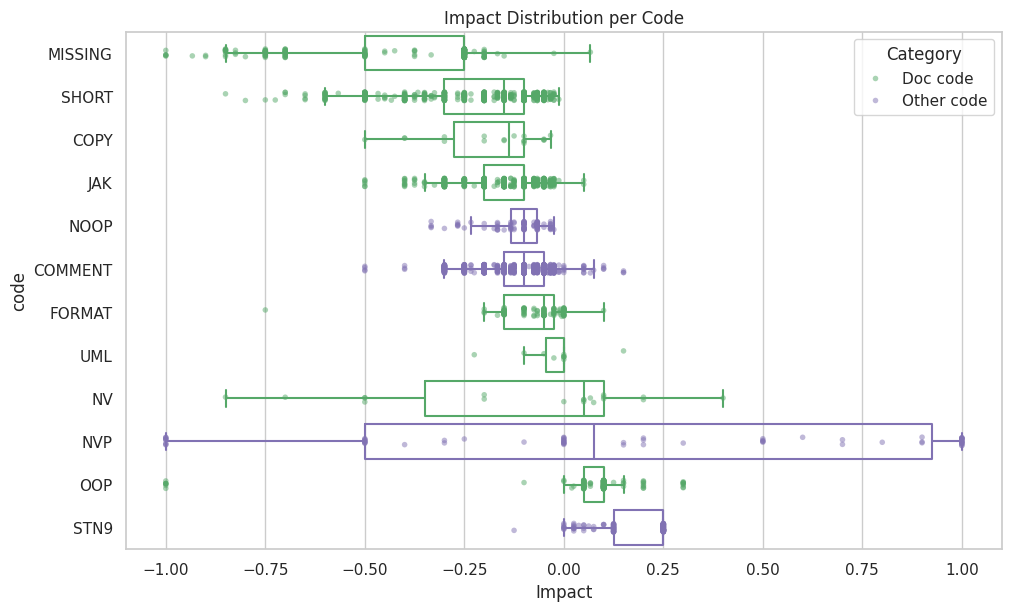

In [47]:
subjective_codes = impact_stats[
    (impact_stats["count"] >= 10) & (impact_stats["std"] > 0.07)
]["code"].tolist()
print(f"High-variance codes: {subjective_codes}")
ax = da.visualise_impact_boxplots(df, codes=subjective_codes)

### Warning vs Penalty Rate

How often graders apply a code as a warning without a specified impact vs an actual deduction vs a bonus.

In [48]:
warnings_df = da.analyse_zero_impact_warnings(df, n_codes=20)
ax = da.visualise_zero_impact_warnings(warnings_df)
da.summarise_zero_impact_warnings(warnings_df)

penalty_type,Bonus (>0),Penalty (<0),Warning (0),total,warning_pct
code,,,,,
CH,0,2489,79,2568,3.1
COMMENT,17,1313,5,1335,0.4
IR,3,1066,1,1070,0.1
JAK,2,987,0,989,0.0
STYLE,1,931,6,938,0.6
SHORT,0,905,0,905,0.0
FILO,5,690,0,695,0.0
LANG,0,564,81,645,12.6
TERM,2,524,8,534,1.5


BLOK and SAZBA strangely contain some bonuses. Parser can be at fault in cases like this due to cases where a bonus cannot be reliably attributed to other codes. 

see raw_text column

In [49]:
rows = df[df["code"].str.upper().isin(["BLOK", "SAZBA"]) & (df["impact"] > 0)].copy()
rows = rows.sort_values(["code", "year"])
display(
    rows[["id", "year", "task_variant", "code", "impact", "impact_source", "raw_text", "comment"]]
    .reset_index(drop=True)
)

,id,year,task_variant,code,impact,impact_source,raw_text,comment
0,REDACTED_STUDENT,2014,py,BLOK,20.0,suffix,"BLOK, pěkný obrázek +20,",pěkný obrázek
1,REDACTED_STUDENT,2015,php,BLOK,50.0,suffix,"BLOK, pěkná dokumentace (+50)",pěkná dokumentace
2,REDACTED_STUDENT,2015,py,BLOK,10.0,suffix,"BLOK, jinak pěkné (+10)",jinak pěkné
3,REDACTED_STUDENT,2015,php,SAZBA,10.0,suffix,"SAZBA epsilon +10 (i když ne nejvhodnější),",epsilon (i když ne nejvhodnější)
4,REDACTED_STUDENT,2015,php,SAZBA,15.0,suffix,"SAZBA (pěkné) +15,",pěkné
5,REDACTED_STUDENT,2015,php,SAZBA,10.0,suffix,SAZBA +10,NaN


### Shared vs Individual Penalties

Some penalties cover a group of codes at once. This shows which codes are most shifted by shared penalties. (e.g. `STRUCT/SHORT -10` vs `STRUCT -5`)

These shared penalties are omitted from analysis elsewhere.

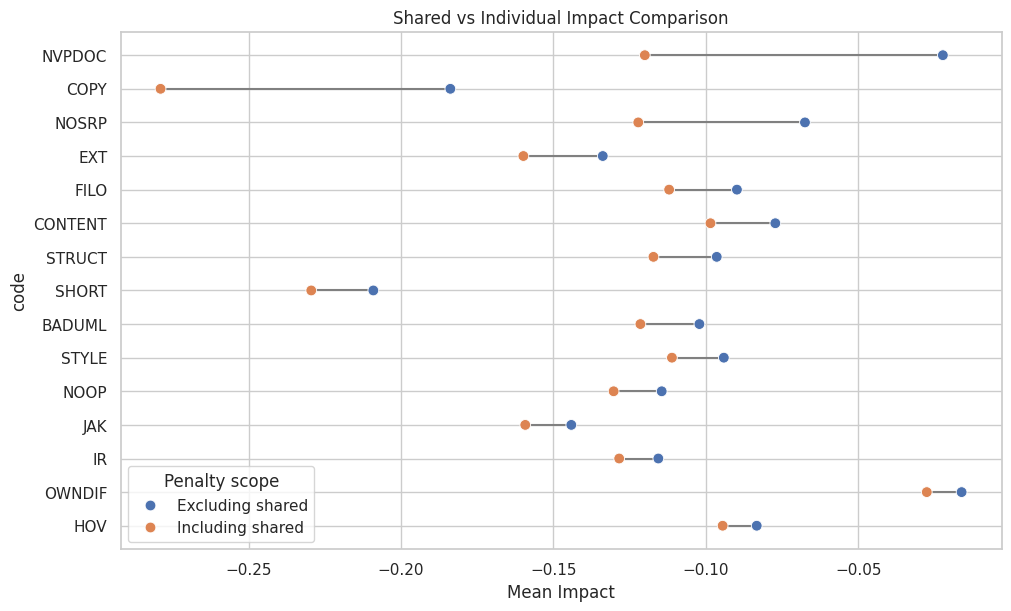

In [50]:
ax = da.visualise_shared_vs_individual_impact(df)

## 5. Trends Over Time

### Code Usage Over Time

Fraction of projects that received each code per year. Shaded area shows 95% confidence interval.

Documentation-specific codes:

In [51]:
from scripts.dataset_parser import DOC_CODES

doc_df = df[df["code"].isin(DOC_CODES)]
top_doc_codes = doc_df["code"].value_counts().head(12).index.tolist()
g = da.visualise_code_usage_trends(proj, codes=top_doc_codes)

Codes in general:

In [52]:
other_codes = df[~df["code"].isin(top_doc_codes)]["code"].value_counts().head(12).index.tolist()
g = da.visualise_code_usage_trends(proj, codes=other_codes)

### Code Impact Over Time

Mean normalised impact per code per year, shows whether grading has become stricter or more lenient.

In [53]:
g = da.visualise_code_impact_trends(df, n_codes=12)

## 6. Code Relationships

### Co-occurrence

Pearson correlation between code presence across projects. Codes that cluster together tend to be applied to the same submissions.

In [54]:
ax = da.visualise_code_cooccurrence(proj, n_codes=15)

### Correlation with Documentation Score

Pearson correlation between receiving a code and the final normalised documentation score. Negative = lower score.

In [55]:
ax = da.visualise_code_points_correlation(proj, n_codes=30)

Possible survivor bias in KAPTXT and SPACETAB.

## 7. Grader Comments

Graders can attach a free-text comment to any code.

### Comment Presence

Which codes are most frequently accompanied by an explanatory comment?

In [56]:
comment_presence = da.analyse_comment_presence(df)

print("Codes where graders frequently add a comment:")
display(comment_presence.head(15))

print("\nCodes where graders rarely add a comment:")
display(
    comment_presence[
        (comment_presence["total_events"] >= 50)
        & (comment_presence["pct_commented"] <= 0.20)
    ]
)


Codes where graders frequently add a comment:


,code,total_events,with_comment,pct_commented
0,DOCTYPE,35,35,1.000000
1,UML,120,114,0.950000
2,MDLINES,37,34,0.918919
3,FORMAT,258,231,0.895349
4,SINGLETON,28,24,0.857143
5,NV,69,56,0.811594
6,HOW,225,182,0.808889
7,OWNDIF,15,12,0.800000
8,NVP,167,132,0.790419
9,MISSING,423,315,0.744681



Codes where graders rarely add a comment:


,code,total_events,with_comment,pct_commented
42,BLOK,2103,364,0.173086
44,NOUML,117,15,0.128205
45,ICH,1216,151,0.124178
46,PSR12,79,9,0.113924
49,MEZ,144,13,0.090278
50,AUTHOR,1364,123,0.090176
52,STN9,213,17,0.079812
53,KAPTXT,406,22,0.054187
54,OK,902,42,0.046563
55,SPACETAB,174,5,0.028736


### Comment Length

Distribution of comment character lengths across all code usage.

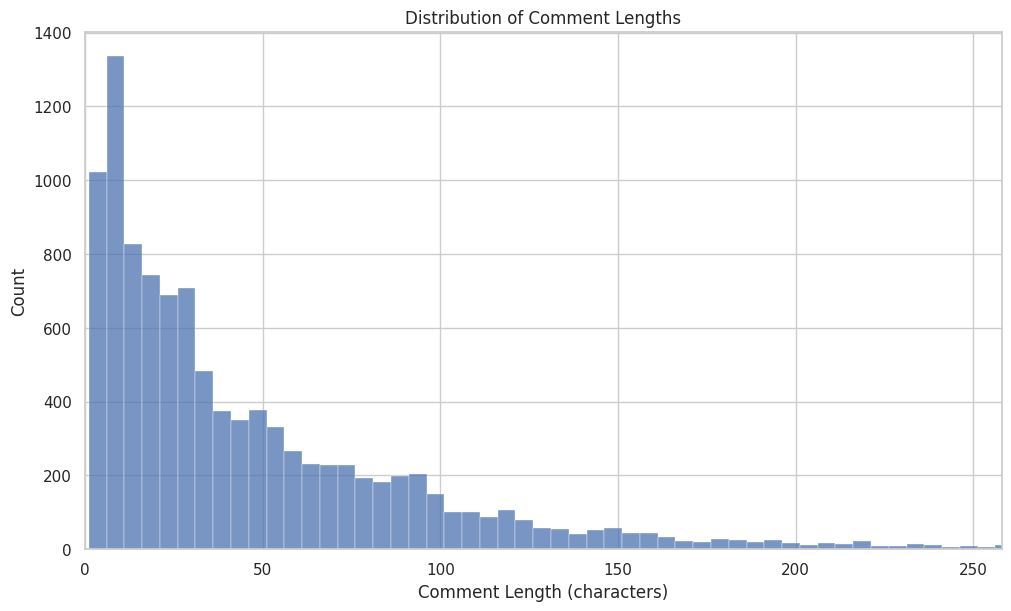

,code,count,mean,median,max
0,DP,10,148.200000,84.0,392
1,HOW,182,110.324176,103.0,263
2,EXT,3,108.000000,10.0,304
3,BADDP,7,89.428571,73.0,167
4,CONTENT,312,81.955128,54.0,731
5,NOSRP,23,81.434783,70.0,202
6,STRUCT,300,79.736667,62.0,731
7,STYLE,414,77.640097,58.0,731
8,NVP,132,74.674242,51.0,793
9,FORMAT,231,70.991342,52.0,731


In [57]:
comment_length_df = da.analyse_comment_length(df)
ax = da.visualise_comment_length(comment_length_df)
da.summarise_comment_length(comment_length_df).head(10)

### Language

Most comments are in Czech, with a smaller Slovak and English fraction. Done with `langdetect` library, so not too reliable. Comments that are too short, non-alphabetical or otherwise hard to pinpoint the language of are classified as unknown. 

In [58]:
language_df = da.analyse_language_distribution(df)

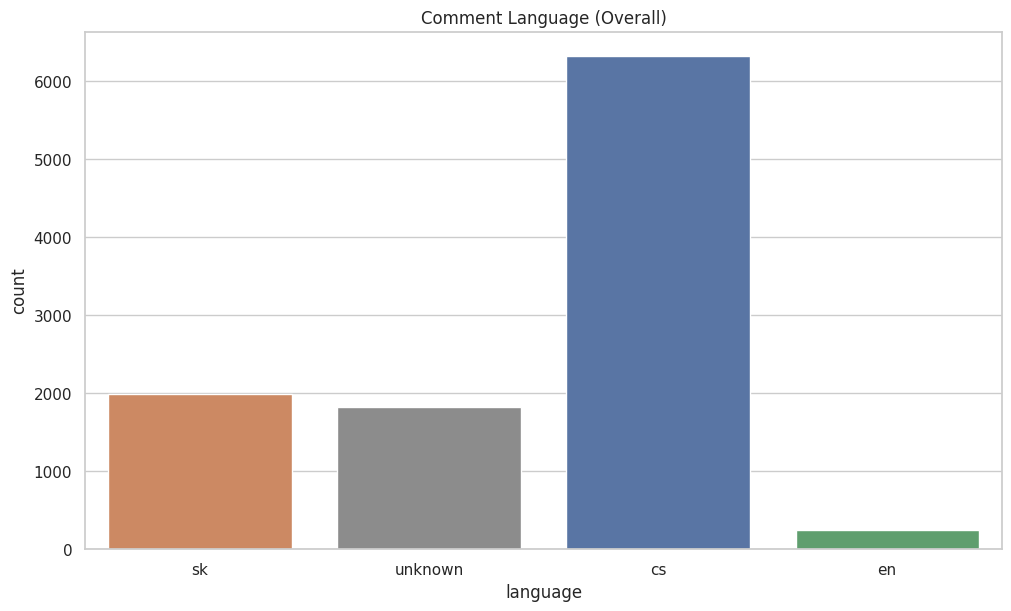

language
cs         6321
sk         1993
unknown    1824
en          248
Name: count, dtype: int64

In [59]:
ax = da.visualise_language_distribution_overall(language_df)
da.summarise_language_distribution(language_df)

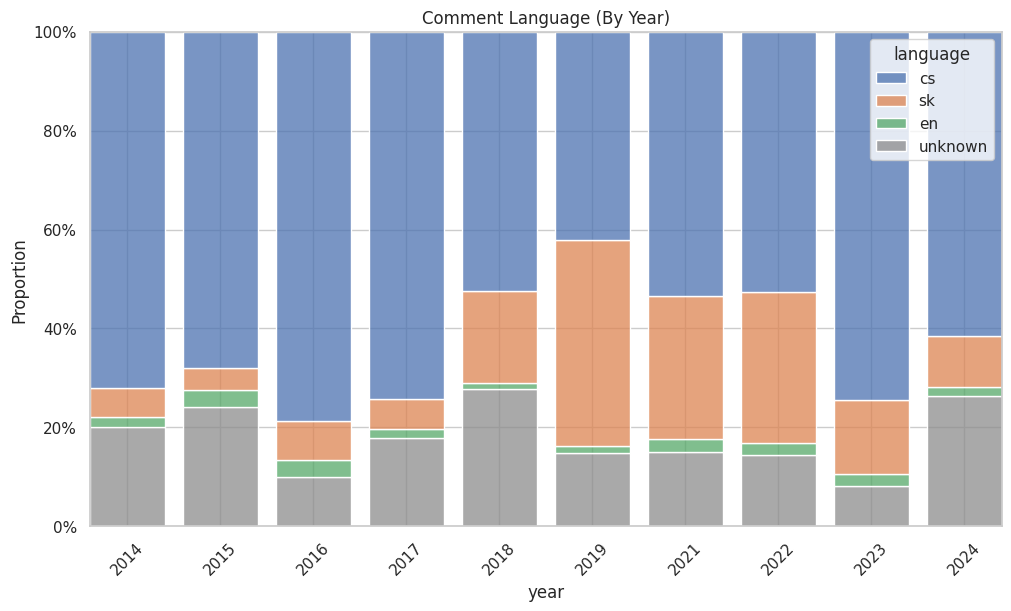

In [60]:
ax = da.visualise_language_distribution_by_year(language_df)

In [61]:
for lang_tag in ["unknown", "en"]:
    sample = (
        language_df[language_df["language"] == lang_tag]
        [["year", "task_variant", "code", "comment"]]
        .drop_duplicates(subset=["comment"])
        .head(10)
        .reset_index(drop=True)
    )
    print(f"Examples of '{lang_tag}'")
    display(sample)


Examples of 'unknown'


,year,task_variant,code,comment
0,2021,par,IR,.
1,2021,par,JAK,XML
2,2021,par,JAK,"kontroly, XML"
3,2021,par,TERM,legální
4,2021,par,HOV,regexů
5,2021,par,LANG,"parsuje, pole stringů"
6,2021,par,CH,ke kontrole validnosti
7,2021,par,LANG,"attributu, elementy pole"
8,2021,par,LANG,"cicle, readline, labelů, ..."
9,2021,par,LANG,escapnuté


Examples of 'en'


,year,task_variant,code,comment
0,2021,par,JAK,operandy
1,2021,par,TERM,FILE -10
2,2021,par,LANG,"dictionary, design pattern"
3,2021,par,LANG,switche
4,2021,par,LANG,"subject, pattern, listenera, observera"
5,2021,par,LANG,"string*, switchem"
6,2021,par,LANG,"- whitespace, návestie"
7,2021,par,FORM,- Xmlwriter
8,2021,par,NVP,"factory, pekné"
9,2021,par,NVP,factory


### Top Keywords

Most frequent words in grader comments after Czech/Slovak stopword removal, with the codes they appear alongside most often.

In [62]:
keywords = da.analyse_comment_keywords(df, n_keywords=30)
keywords

,keyword,count,top_codes
0,popis,1368,"SHORT, FILO, HOW"
1,postrádám,897,"COMMENT, HOW, CH"
2,interpunkce,766,"CH, STYLE, HOV"
3,chybí,623,"FILO, SHORT, COMMENT"
4,implementace,608,"HOW, SHORT, STRUCT"
5,celkově,506,"HOW, SHORT, COMMENT"
6,dokumentace,480,"CONTENT, SHORT, FORMAT"
7,preciznější,444,"HOW, SHORT, STRUCT"
8,nehodnoceno,380,"BLOK, PRED, COMMENT"
9,překlepy,355,"CH, COMMENT, LANG"


## HOV

`HOV` (hovorový styl) is assigned when a student document contains informal, colloquial, or inappropriate language. Here are all the grader comments clarifying the code.

In [63]:
hov_df = df.query("code == 'HOV' and not impact_shared")

hov_df = (
    hov_df.loc[hov_df["raw_text"].notna(), ["year", "task_variant", "raw_text"]]
    .drop_duplicates(subset=["raw_text"])
    .sort_values("year")
    .reset_index(drop=True)
)

# with pd.option_context("display.max_colwidth", None, "display.max_rows", None):
#     display(hov_df)

display(hov_df)

,year,task_variant,raw_text
0,2014,php,"HOV (věcí, šlo) -10mb,"
1,2014,py,HOV
2,2014,php,"HOV (pošlou, smažou)"
3,2014,py,"HOV (prohnán) -15,"
4,2014,php,"HOV (sahám), zdrojový kód není dekomponován do..."
...,...,...,...
163,2024,par,"HOV (visitor není standardně užívaný pojem),"
164,2024,par,"HOV (př. Edge casy), celkově značně zjednodušeno"
165,2024,par,"HOV (taky), celkově postrádám detailnější popi..."
166,2024,par,"HOV (""vypíšu"")"
